# Noise-floor comparison: is EngressNet's SIT bias within natural internal variability?

Following the noise-floor framing from Cachay et al. 2024, ["Probabilistic Emulation of a
Global Climate Model with Spherical DYffusion"](https://arxiv.org/abs/2406.14798) (Section
5.3 / Table 2): a climate emulator's time-mean bias is only meaningful as a *model deficiency*
if it exceeds the spread you'd see between independent realizations of the *true* system just
from unforced internal (chaotic) variability -- decadal weather is not exactly reproducible
even by a perfect model. They estimate this "noise floor" from a 10-member reference-model
ensemble (same physics-based model, different initial conditions) and report their emulator's
bias as a percentage relative to it.

**Adaptation here**: we don't have an initial-condition ensemble of FOSI (the single
trajectory EngressNet is trained/tested against). Instead we use MESACLIP -- a 9-member CESM1
"ihesp-hires" ensemble (historical + RCP8.5, `/gdex/data/d651007` + `/gdex/data/d651009`)
that differs across members only in ocean/atmosphere initial conditions -- as a same-model-class
proxy for internal variability: the spread of 10-year time-mean sea ice thickness *across those
9 members* stands in for the noise floor.

**Caveat**: MESACLIP (CESM1, `ne120_t12` grid) is a different model configuration and native
grid than FOSI (CESM2 FOSI-HR, `TL319_t13` grid) that trained/tests EngressNet, and its members
share a scenario-forced (historical+RCP8.5) rather than FOSI's repeating-climatology JRA
forcing. So this is *not* a strict identical-model IC ensemble like the paper's 10 FV3GFS
runs -- treat the resulting ratios as an order-of-magnitude argument (bias comparable to
natural noise, vs. clearly larger than it), not a formal significance test.

This notebook reads only `<output_dir>/eval_data/` (written by `save_evaluation_data()` --
see `functions_engressnet.py`) for the EngressNet side, same as `evaluation_plots.ipynb`, plus
MESACLIP sea ice thickness (`hi`) read directly from the CESM archive for the noise-floor side.
Only meaningful for `--no-patches` runs (single coherent target grid).


In [2]:
import re
from pathlib import Path
from glob import glob
import pickle
import json

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from IPython.display import display
from scipy.spatial import cKDTree


## Config

In [3]:
# Point this at a single run's eval_data/ directory (same convention as evaluation_plots.ipynb)
DIR = Path("/glade/work/skygale/_projects/SeaIceDownscaling/Version4/results/FOSI_2conv")
RUN = "FOSI_nopatches_1990-2000_2010-2020_5280657.casper-pbs"
EVAL_DIR = DIR / RUN / "eval_data"
assert EVAL_DIR.exists(), f"EVAL_DIR does not exist: {EVAL_DIR}"
print("EVAL_DIR:", EVAL_DIR)


EVAL_DIR: /glade/work/skygale/_projects/SeaIceDownscaling/Version4/results/FOSI_2conv/FOSI_nopatches_1990-2000_2010-2020_5280657.casper-pbs/eval_data


In [4]:
# Mirrors evaluation_plots.ipynb's save_fig/save_table -- namespaced under saved_figs/noise_floor/
# so re-running against a different EVAL_DIR never clobbers a previous run's output.
SAVE_DIR = Path("saved_figs") / "noise_floor" / DIR.name / RUN
SAVE_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name):
    fig.savefig(SAVE_DIR / f"{name}.png", dpi=150, bbox_inches="tight")


def save_table(df, name):
    df.to_csv(SAVE_DIR / f"{name}.csv")


print("Saving figures/tables to:", SAVE_DIR.resolve())


Saving figures/tables to: /glade/work/skygale/_projects/SeaIceDownscaling/Version4/saved_figs/noise_floor/FOSI_2conv/FOSI_nopatches_1990-2000_2010-2020_5280657.casper-pbs


## Load EngressNet evaluation data

In [5]:
fields = np.load(EVAL_DIR / "fields.npz")
Y_pred_phys = fields["Y_pred_phys"]   # (N, 1, H, W) stochastic UNet ensemble-mean SIT
Y_test_phys = fields["Y_test_phys"]   # (N, 1, H, W) truth (FOSI) SIT
mask_test = fields["mask_test"]       # (N, C_mask, H, W) land mask per test sample/tile

with open(EVAL_DIR / "tile_geometry.pkl", "rb") as f:
    tile_geometry = pickle.load(f)   # list of dicts: context_lon/lat, target_lon/lat per tile

with open(EVAL_DIR / "meta.json") as f:
    meta = json.load(f)

bbox = meta["bbox"]
use_patches = meta["use_patches"]
candidate_points = meta["candidate_points"]   # {name: {"lat":.., "lon":.. (0-360)}}

sample_times_df = pd.read_csv(EVAL_DIR / "sample_times.csv", parse_dates=["time"])

assert not use_patches, "Noise-floor comparison needs a single coherent target grid (--no-patches run)."

geo = tile_geometry[0]
target_lat, target_lon = geo["target_lat"], geo["target_lon"]   # 1D, lon in [0, 360)
land_mask_hw = mask_test[0, 0]                                  # (H, W); same crop for every no-patch sample

print("N test samples:", Y_test_phys.shape[0], " | target grid:", target_lat.shape[0], "x", target_lon.shape[0])
print("Test period:", sample_times_df["time"].min().date(), "to", sample_times_df["time"].max().date())


N test samples: 132  | target grid: 150 x 310
Test period: 2010-01-01 to 2020-12-01


In [6]:
# Point Hope postdates whichever training run wrote this eval_data/ -- add it directly if
# missing, same as evaluation_plots.ipynb (no retraining needed; the point lookup below works
# straight off the saved fields).
POINT_HOPE_LAT = 68.3415
POINT_HOPE_LON_360 = -166.7578 % 360
candidate_points = {**candidate_points, "Point Hope": {"lat": POINT_HOPE_LAT, "lon": POINT_HOPE_LON_360}}
print("Candidate points:", list(candidate_points.keys()))


Candidate points: ['Kivalina', 'Shishmaref', 'Kotzebue', 'Nome', 'Point Hope']


## Shared map styling

In [7]:
def rounded_boundary_path(proj, lon_min, lon_max, lat_min, lat_max, n=50):
    """Quadrilateral Axes-boundary path (in projected coords) tracing the given lon/lat box."""
    lons = np.concatenate([
        np.linspace(lon_min, lon_max, n), np.full(n, lon_max),
        np.linspace(lon_max, lon_min, n), np.full(n, lon_min),
    ])
    lats = np.concatenate([
        np.full(n, lat_min), np.linspace(lat_min, lat_max, n),
        np.full(n, lat_max), np.linspace(lat_max, lat_min, n),
    ])
    pts = proj.transform_points(ccrs.PlateCarree(), lons, lats)
    return mpath.Path(pts[:, :2])


def make_polar_proj(bbox, n=50):
    central_lon = (bbox["lon_min"] + bbox["lon_max"]) / 2
    proj = ccrs.NorthPolarStereo(central_longitude=central_lon)
    boundary_path = rounded_boundary_path(
        proj, bbox["lon_min"], bbox["lon_max"], bbox["lat_min"], bbox["lat_max"], n
    )
    return proj, boundary_path, central_lon


def style_polar_ax(ax, proj, boundary_path, bbox, lon_=None, lat_=None, pad_frac=0.001,
                    points=None, point_color="red"):
    """Coastlines, land, domain boundary, candidate-point markers, gridlines."""
    lon_min = bbox["lon_min"] % 360
    lon_max = bbox["lon_max"] % 360

    ax.coastlines(resolution="50m")
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)

    if lon_ is not None and lat_ is not None:
        lo0, lo1 = float(np.min(lon_)), float(np.max(lon_))
        la0, la1 = float(np.min(lat_)), float(np.max(lat_))
        pad_lo = (lo1 - lo0) * pad_frac or 0.5
        pad_la = (la1 - la0) * pad_frac or 0.5
        ext_lo0, ext_lo1 = lo0 - pad_lo, lo1 + pad_lo
        ext_la0, ext_la1 = la0 - pad_la, la1 + pad_la
        ax.set_extent([ext_lo0, ext_lo1, ext_la0, ext_la1], crs=ccrs.PlateCarree())
        panel_boundary = rounded_boundary_path(proj, ext_lo0, ext_lo1, ext_la0, ext_la1)
    else:
        ax.set_extent([lon_min, lon_max, bbox["lat_min"], bbox["lat_max"]], crs=ccrs.PlateCarree())
        panel_boundary = boundary_path

    ax.set_boundary(panel_boundary, transform=proj)

    if points is None:
        points = candidate_points
    for name, pt in points.items():
        ax.plot(pt["lon"], pt["lat"], marker="*", color=point_color, markersize=10, transform=ccrs.PlateCarree())
        ax.text(pt["lon"] + 1, pt["lat"] + 0.35, name, color=point_color, fontsize=7, transform=ccrs.PlateCarree())

    ax.gridlines(draw_labels=False, linestyle="--", alpha=0.4)


proj, boundary_path, central_lon = make_polar_proj(bbox)


## MESACLIP: 9-member internal-variability reference ensemble

Sea ice thickness (`hi`, monthly) from the 9-member MESACLIP historical+RCP8.5 ensemble,
cropped to the same bounding box as EngressNet's domain (`functions_engressnet.DEFAULT_BBOX`).
Only the 10-year chunk files overlapping the run's own test period are opened -- for the
standard 2010-2020 test split that's fully inside the RCP8.5 scenario period (2006-2100), so
no historical-period files are needed at all.


In [8]:
# lon in degrees_east, lat in degrees_north -- identical to functions_engressnet.DEFAULT_BBOX
MESA_BBOX = bbox


def bbox_ij_slice(tlat, tlon, bb):
    """Index-space (j, i) bounding box enclosing bb on a curvilinear (2D lat/lon) grid."""
    lon_min = bb["lon_min"] % 360
    lon_max = bb["lon_max"] % 360
    tlon360 = tlon % 360
    m = (tlat >= bb["lat_min"]) & (tlat <= bb["lat_max"]) & (tlon360 >= lon_min) & (tlon360 <= lon_max)
    jj, ii = np.where(m.values if hasattr(m, "values") else m)
    return slice(int(jj.min()), int(jj.max()) + 1), slice(int(ii.min()), int(ii.max()) + 1)


def fill_nan_coord(da):
    """MESACLIP sets TLAT/TLON to NaN over all-land computational blocks (hi is NaN/0 at
    those same cells already), so it's safe to fill the coordinate gaps from neighbors --
    needed for the KDTree regrid below to accept them."""
    dims = da.dims
    return da.ffill(dims[0]).bfill(dims[0]).ffill(dims[1]).bfill(dims[1])


def files_covering_years(file_list, year_min, year_max):
    """Keep only the 10-year-chunk files (named ..YYYYMM-YYYYMM.nc) overlapping
    [year_min, year_max] -- avoids reading a member's full 1920-2100 record to average one
    decade."""
    kept = []
    for fp in file_list:
        m = re.search(r"(\d{6})-(\d{6})\.nc$", fp)
        if not m:
            kept.append(fp)  # unexpected naming -- keep rather than silently drop
            continue
        f_start, f_end = int(m.group(1)[:4]), int(m.group(2)[:4])
        if f_end >= year_min and f_start <= year_max:
            kept.append(fp)
    return kept


def open_hi_for_years(run_dirs, year_min, year_max):
    """Open 'hi'+TLAT/TLON from whichever of run_dirs has chunk files overlapping the
    requested years (skips a directory entirely if it has none, e.g. the historical
    directory when [year_min, year_max] is fully inside the RCP8.5 period)."""
    datasets = []
    for d in run_dirs:
        files = sorted(glob(f"{d}/ice/proc/tseries/month_1/*.hi.*.nc"))
        files = files_covering_years(files, year_min, year_max)
        if files:
            datasets.append(xr.open_mfdataset(files, combine="by_coords")[["hi", "TLAT", "TLON"]])
    if not datasets:
        raise FileNotFoundError(f"No hi chunk files found covering {year_min}-{year_max} in {run_dirs}")
    return xr.concat(datasets, dim="time") if len(datasets) > 1 else datasets[0]


In [9]:
dir_hist = "/gdex/data/d651007"
dir_rcp85 = "/gdex/data/d651009"

hist_dirs = sorted(glob(f"{dir_hist}/*ihesp-hires*"))
rcp85_dirs = sorted(glob(f"{dir_rcp85}/*ihesp-hires*"))
# both dir names end in the same 3-digit ensemble suffix (e.g. "...002") -- match on that
member_ids = [d[-3:] for d in hist_dirs]
assert member_ids == [d[-3:] for d in rcp85_dirs], "historical/RCP8.5 member ordering does not match"
print(f"MESACLIP members ({len(member_ids)}):", member_ids)


MESACLIP members (9): ['002', '003', '004', '005', '006', '007', '008', '009', '010']


In [10]:
# The noise floor is estimated over the identical decade this run was evaluated on, not
# just "any 10 MESACLIP years" -- so it's directly comparable to EngressNet's own bias below.
YEAR_MIN = int(sample_times_df["time"].dt.year.min())
YEAR_MAX = int(sample_times_df["time"].dt.year.max())
print(f"Test period for noise-floor estimate: {YEAR_MIN}-{YEAR_MAX}")

mesa_member_means = []
mesa_lat2d = mesa_lon2d = None
nj_sl_mesa = ni_sl_mesa = None

for hdir, rdir, mid in zip(hist_dirs, rcp85_dirs, member_ids):
    ds = open_hi_for_years([hdir, rdir], YEAR_MIN, YEAR_MAX)
    if nj_sl_mesa is None:
        nj_sl_mesa, ni_sl_mesa = bbox_ij_slice(ds.TLAT, ds.TLON, MESA_BBOX)
        mesa_lat2d = fill_nan_coord(ds.TLAT.isel(nj=nj_sl_mesa, ni=ni_sl_mesa))
        mesa_lon2d = fill_nan_coord(ds.TLON.isel(nj=nj_sl_mesa, ni=ni_sl_mesa))
    da = ds["hi"].isel(nj=nj_sl_mesa, ni=ni_sl_mesa)
    da = da.sel(time=(da["time"].dt.year >= YEAR_MIN) & (da["time"].dt.year <= YEAR_MAX))
    # compute (not leave lazy) member-by-member so the 9-member read stays a bounded, visible cost
    mesa_member_means.append(da.mean(dim="time").compute())
    print(f"  member {mid}: {da.sizes['time']} months averaged")

mesa_member_mean_native = xr.concat(mesa_member_means, dim="member_id").assign_coords(member_id=member_ids)
print("mesa_member_mean_native:", mesa_member_mean_native.shape)


Test period for noise-floor estimate: 2010-2020


/glade/derecho/scratch/skygale/tmp/ipykernel_65029/2954589068.py:48: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  datasets.append(xr.open_mfdataset(files, combine="by_coords")[["hi", "TLAT", "TLON"]])


  member 002: 132 months averaged


/glade/derecho/scratch/skygale/tmp/ipykernel_65029/2954589068.py:48: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  datasets.append(xr.open_mfdataset(files, combine="by_coords")[["hi", "TLAT", "TLON"]])


  member 003: 132 months averaged


...

  member 008: 132 months averaged


/glade/derecho/scratch/skygale/tmp/ipykernel_65029/2954589068.py:48: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  datasets.append(xr.open_mfdataset(files, combine="by_coords")[["hi", "TLAT", "TLON"]])


  member 009: 132 months averaged


/glade/derecho/scratch/skygale/tmp/ipykernel_65029/2954589068.py:48: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  datasets.append(xr.open_mfdataset(files, combine="by_coords")[["hi", "TLAT", "TLON"]])


  member 010: 132 months averaged
mesa_member_mean_native: (9, 434, 474)


## Regrid onto the target grid + compute the noise floor

In [11]:
def to_xyz(lat_deg, lon_deg):
    lat, lon = np.deg2rad(lat_deg), np.deg2rad(lon_deg)
    return np.stack([np.cos(lat) * np.cos(lon), np.cos(lat) * np.sin(lon), np.sin(lat)], axis=-1)


def nearest_grid_indices(src_lat, src_lon, query_lat, query_lon):
    """Flat index into src_lat/src_lon.ravel() of the nearest source cell to each query
    point, via a 3D-Cartesian KDTree (robust near the pole/dateline unlike plain lat/lon
    distance) -- same approach as build_piomas_regridded in evaluation_plots.ipynb."""
    tree = cKDTree(to_xyz(np.asarray(src_lat).ravel(), np.asarray(src_lon).ravel()))
    _, idx = tree.query(to_xyz(np.asarray(query_lat), np.asarray(query_lon)))
    return idx


tlat_2d, tlon_2d = np.meshgrid(target_lat, target_lon, indexing="ij")
space_idx = nearest_grid_indices(mesa_lat2d.values, mesa_lon2d.values % 360, tlat_2d.ravel(), tlon_2d.ravel())

mesa_native_flat = mesa_member_mean_native.values.reshape(len(member_ids), -1)     # (M, nj*ni)
mesa_regridded = mesa_native_flat[:, space_idx].reshape(len(member_ids), *tlat_2d.shape)   # (M, H, W)

# Table-2-style "climate variability": std across the ensemble of decadal time-means, per
# grid cell -- the inter-member spread purely from internal variability (all 9 members share
# the same forcing scenario, differing only in initial conditions).
noise_floor_hw = np.std(mesa_regridded, axis=0)
print("noise_floor_hw:", noise_floor_hw.shape, " | range:", float(np.nanmin(noise_floor_hw)), "-", float(np.nanmax(noise_floor_hw)))


noise_floor_hw: (150, 310)  | range: 9.482212772127241e-05 - 0.20502710342407227


In [12]:
FLAT_STD_TOL = 1e-6  # m of SIT

# cos-lat weighted, ocean-only -- same weighting convention as evaluation_plots.ipynb's
# PIOMAS metrics (section 12), appropriate for a physical spatial average.
ocean_w = np.where(land_mask_hw > 0.5, 0.0, np.cos(np.deg2rad(target_lat))[:, None] * np.ones((1, len(target_lon))))
ocean_w = ocean_w / ocean_w.sum()

domain_noise_floor = float(np.nansum(ocean_w * noise_floor_hw))
print(f"Domain-mean (cos-lat weighted) noise floor: {domain_noise_floor:.4f} m")

# Nearest-valid-cell candidate-point lookup, excluding land AND cells where truth or the
# noise floor itself is ~flat -- the same coastal-flatness issue documented in
# evaluation_plots.ipynb section 2 (bilinear-regridding bleeds the land fill value into
# coastal cells; here a target cell can also map to a MESACLIP source cell that's
# land/permanently ice-free after regridding, giving a spuriously "flat" (std=0) noise floor).
def nearest_valid_index(lat_grid, lon_grid, exclude_hw, point_lat, point_lon_360):
    lat_grid = np.asarray(lat_grid)
    lon_grid = np.asarray(lon_grid) % 360
    dlat_deg = lat_grid[:, None] - point_lat
    dlon_deg = (lon_grid[None, :] - point_lon_360 + 180) % 360 - 180
    dlon_deg = dlon_deg * np.cos(np.deg2rad(point_lat))
    dist2 = dlat_deg ** 2 + dlon_deg ** 2
    valid = ~np.asarray(exclude_hw).astype(bool)
    dist2 = np.where(valid, dist2, np.inf)
    iy, ix = np.unravel_index(np.argmin(dist2), dist2.shape)
    return int(iy), int(ix)


flat_truth_hw = Y_test_phys[:, 0].std(axis=0) < FLAT_STD_TOL
# noise_floor_hw is NaN wherever the KDTree regrid's nearest MESACLIP source cell was itself
# land/missing (hi undefined there) -- `nan < tol` is False in numpy, so without the explicit
# isnan check those cells would silently pass the flatness filter below and could get picked
# as a candidate point's "nearest valid" cell (this is what produced Nome's NaN noise floor).
flat_or_missing_noise_floor_hw = (noise_floor_hw < FLAT_STD_TOL) | np.isnan(noise_floor_hw)
exclude_hw = (land_mask_hw > 0.5) | flat_truth_hw | flat_or_missing_noise_floor_hw

point_noise_floor = {}
for name, pt in candidate_points.items():
    iy, ix = nearest_valid_index(target_lat, target_lon, exclude_hw, pt["lat"], pt["lon"])
    point_noise_floor[name] = float(noise_floor_hw[iy, ix])

point_noise_floor


Domain-mean (cos-lat weighted) noise floor: 0.0562 m


{'Kivalina': 0.048742540180683136,
 'Shishmaref': 0.05117637291550636,
 'Kotzebue': 0.014340054243803024,
 'Nome': 0.032121267169713974,
 'Point Hope': 0.05443328991532326}

## EngressNet's own time-mean bias vs. FOSI truth

In [13]:
bias_hw = np.nanmean(Y_pred_phys[:, 0] - Y_test_phys[:, 0], axis=0)   # (H, W); prediction - truth

domain_bias = float(np.nansum(ocean_w * bias_hw))
domain_bias_rms = float(np.sqrt(np.nansum(ocean_w * bias_hw ** 2)))
print(f"Domain-mean bias vs. FOSI truth: {domain_bias:+.4f} m  (spatial RMS of the bias pattern: {domain_bias_rms:.4f} m)")

point_bias = {}
for name, pt in candidate_points.items():
    iy, ix = nearest_valid_index(target_lat, target_lon, exclude_hw, pt["lat"], pt["lon"])
    point_bias[name] = float(bias_hw[iy, ix])

point_bias


Domain-mean bias vs. FOSI truth: -0.0071 m  (spatial RMS of the bias pattern: 0.0693 m)


{'Kivalina': -0.1700139194726944,
 'Shishmaref': 0.06725555658340454,
 'Kotzebue': -0.03809456154704094,
 'Nome': -0.0322137214243412,
 'Point Hope': -0.06197791546583176}

## Local-footprint diagnostic (coastal candidate points only)

`bias_hw` turns out to be very noisy immediately around the coast -- neighboring cells within
a few km of the same candidate point can swing by 0.1-0.3 m, sign included, consistent with
the coastal bilinear-regridding land-bleed artifact already documented in the `Version4` root
`CLAUDE.md` ("Candidate-point nearest-cell lookup must exclude flat cells, not just land").
That makes a single nearest-cell bias an unstable estimate of a coastal community's actual
bias: the exact grid cell picked can dominate the result. Both regrid steps that place the
candidate point (point -> target grid, target grid -> MESACLIP source grid) were checked
directly and are spatially accurate to a few km, so this is not a mismatched-cell bug -- it's
that a single pixel is the wrong unit of comparison at the coast.

To make that instability visible rather than hiding it behind one number, this section adds an
area-weighted mean (and std) over all valid cells within `FOOTPRINT_RADIUS_KM` of each point,
alongside the single-nearest-cell numbers already computed above. Neither is presented as
"the" answer -- the comparison table below reports both, plus an explicit flag for when the
local bias std is at least as large as the local mean bias (i.e. the point-scale signal is
noise-dominated, not a clean systematic bias).


In [14]:
# ---- customize here ----
FOOTPRINT_RADIUS_KM = 25.0
# -------------------------

def footprint_mask(lat_grid, lon_grid, excl, point_lat, point_lon_360, radius_km):
    """Boolean (H, W) mask of valid (non-excluded) cells within radius_km of a point -- same
    flat-earth-with-cos(lat)-correction distance as nearest_valid_index, thresholded instead
    of argmin'd."""
    lat_grid = np.asarray(lat_grid)
    lon_grid = np.asarray(lon_grid) % 360
    dlat_deg = lat_grid[:, None] - point_lat
    dlon_deg = (lon_grid[None, :] - point_lon_360 + 180) % 360 - 180
    dlon_deg = dlon_deg * np.cos(np.deg2rad(point_lat))
    dist_km = np.sqrt(dlat_deg ** 2 + dlon_deg ** 2) * 111.0
    valid = ~np.asarray(excl).astype(bool)
    return valid & (dist_km <= radius_km)


point_footprint_bias = {}
point_footprint_bias_std = {}
point_footprint_noise_floor = {}
point_footprint_n = {}
for name, pt in candidate_points.items():
    m = footprint_mask(target_lat, target_lon, exclude_hw, pt["lat"], pt["lon"], FOOTPRINT_RADIUS_KM)
    if not m.any():
        # radius too small to catch any valid cell here -- fall back to the single nearest cell
        iy, ix = nearest_valid_index(target_lat, target_lon, exclude_hw, pt["lat"], pt["lon"])
        m = np.zeros_like(exclude_hw, dtype=bool)
        m[iy, ix] = True
    point_footprint_bias[name] = float(bias_hw[m].mean())
    point_footprint_bias_std[name] = float(bias_hw[m].std())
    point_footprint_noise_floor[name] = float(noise_floor_hw[m].mean())
    point_footprint_n[name] = int(m.sum())

pd.DataFrame({
    "n cells": point_footprint_n,
    "Footprint mean bias (m)": point_footprint_bias,
    "Footprint bias std (m)": point_footprint_bias_std,
    "Footprint mean noise floor (m)": point_footprint_noise_floor,
})


,n cells,Footprint mean bias (m),Footprint bias std (m),Footprint mean noise floor (m)
Kivalina,20,-0.063474,0.063115,0.045446
Shishmaref,27,0.005997,0.090305,0.049947
Kotzebue,25,-0.056657,0.056473,0.018392
Nome,19,-0.011871,0.018450,0.025276
Point Hope,38,-0.075701,0.094768,0.054787


## Comparison table

Mirrors the paper's framing: is EngressNet's bias smaller than, comparable to, or clearly
larger than the spread you'd see between independent MESACLIP realizations of the same decade
(i.e. is it distinguishable from natural internal variability)? Reports both the single
nearest-cell number and the local-footprint mean side by side (see above) -- read a point row
as unreliable if "Noise-dominated?" is True, regardless of which ratio column looks alarming.


In [15]:
rows = [{
    "Region": "Domain mean",
    "EngressNet bias (m)": round(domain_bias, 4),
    "Noise floor: MESACLIP inter-member std (m)": round(domain_noise_floor, 4),
    "|bias| / noise floor (%)": round(100 * abs(domain_bias) / domain_noise_floor, 1),
    "Footprint mean bias (m)": np.nan,
    "Footprint bias std (m)": np.nan,
    "Footprint |bias| / noise floor (%)": np.nan,
    "Noise-dominated? (footprint std >= |mean bias|)": np.nan,
}]
for name in candidate_points:
    nf = point_noise_floor[name]
    b = point_bias[name]
    fb = point_footprint_bias[name]
    fb_std = point_footprint_bias_std[name]
    fnf = point_footprint_noise_floor[name]
    footprint_ratio = 100 * abs(fb) / fnf if fnf > 0 else float("nan")
    rows.append({
        "Region": name,
        "EngressNet bias (m)": round(b, 4),
        "Noise floor: MESACLIP inter-member std (m)": round(nf, 4),
        "|bias| / noise floor (%)": round(100 * abs(b) / nf, 1) if nf > 0 else float("nan"),
        "Footprint mean bias (m)": round(fb, 4),
        "Footprint bias std (m)": round(fb_std, 4),
        "Footprint |bias| / noise floor (%)": round(footprint_ratio, 1),
        "Noise-dominated? (footprint std >= |mean bias|)": fb_std >= abs(fb),
    })

noise_floor_summary_df = pd.DataFrame(rows)
noise_floor_summary_df["Within noise floor? (single cell)"] = noise_floor_summary_df["|bias| / noise floor (%)"] <= 100
# footprint columns are NaN for the domain row (footprint diagnostic is candidate-point only) --
# "NaN <= 100" silently evaluates to False in numpy/pandas, so guard explicitly to keep it NaN
# there instead of a misleading False.
footprint_pct = noise_floor_summary_df["Footprint |bias| / noise floor (%)"]
noise_floor_summary_df["Within noise floor? (footprint mean)"] = np.where(
    footprint_pct.isna(), np.nan, footprint_pct <= 100
)
save_table(noise_floor_summary_df, "noise_floor_summary")
display(noise_floor_summary_df)


,Region,EngressNet bias (m),Noise floor: MESACLIP inter-member std (m),|bias| / noise floor (%),Footprint mean bias (m),Footprint bias std (m),Footprint |bias| / noise floor (%),Noise-dominated? (footprint std >= |mean bias|),Within noise floor? (single cell),Within noise floor? (footprint mean)
0,Domain mean,-0.0071,0.0562,12.6,NaN,NaN,NaN,NaN,True,NaN
1,Kivalina,-0.1700,0.0487,348.8,-0.0635,0.0631,139.7,False,False,0.0
2,Shishmaref,0.0673,0.0512,131.4,0.0060,0.0903,12.0,True,False,1.0
3,Kotzebue,-0.0381,0.0143,265.7,-0.0567,0.0565,308.0,False,False,0.0
4,Nome,-0.0322,0.0321,100.3,-0.0119,0.0184,47.0,True,False,1.0
5,Point Hope,-0.0620,0.0544,113.9,-0.0757,0.0948,138.2,True,False,0.0


## Spatial comparison (paper Fig. 5 style)

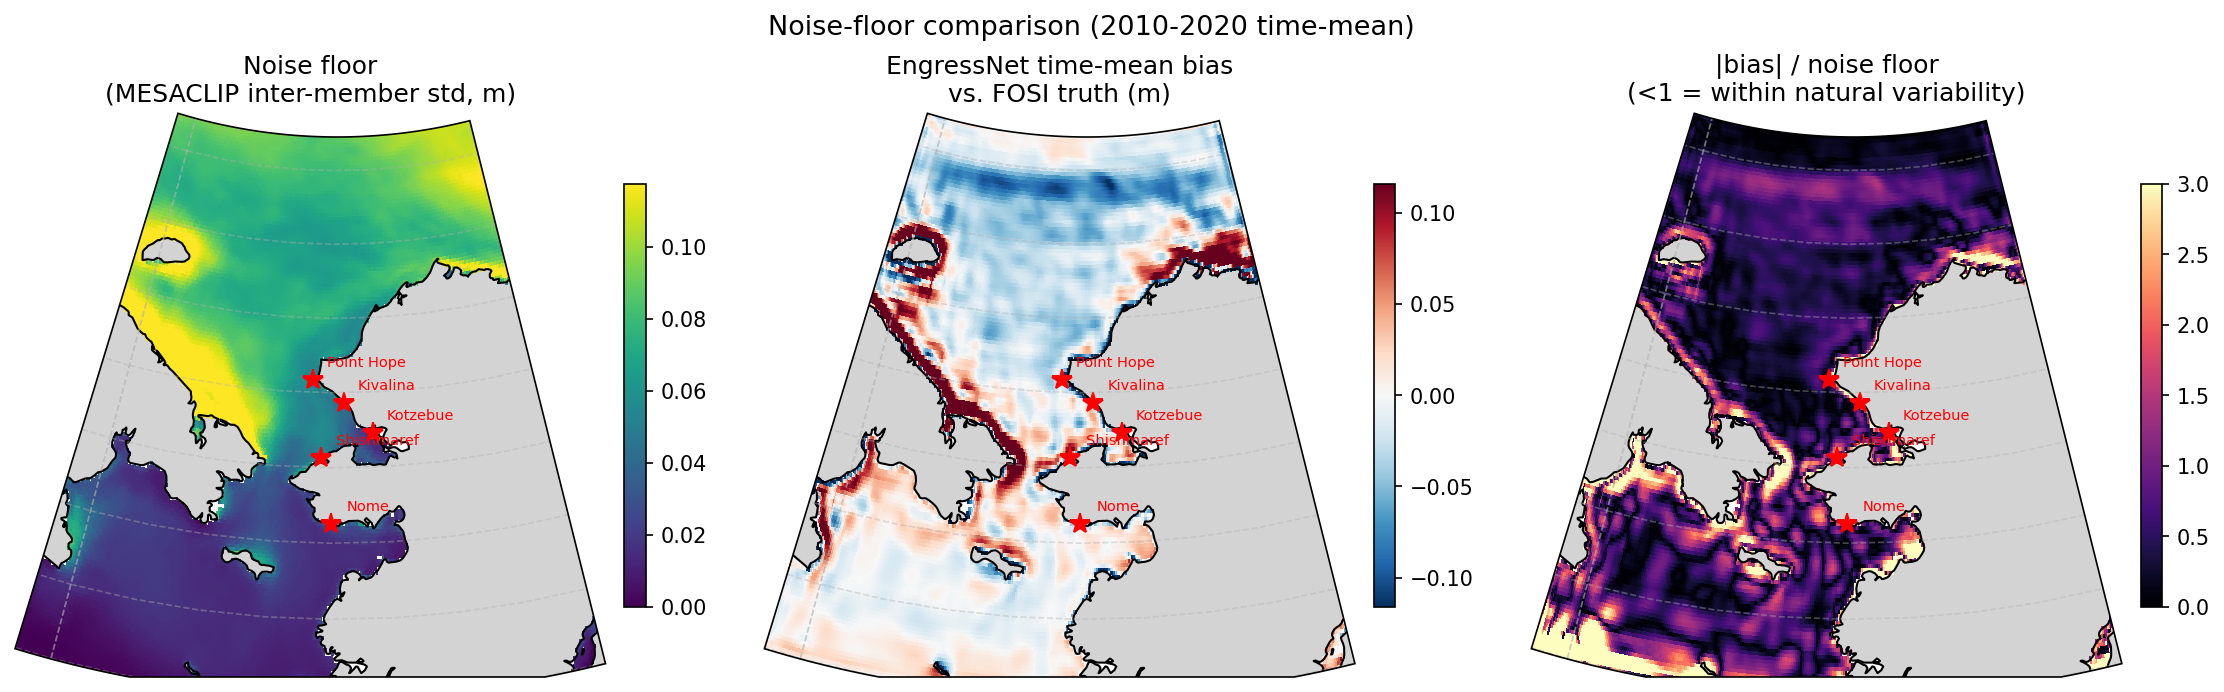

In [16]:
# ---- customize here ----
NF_VMAX = float(np.nanpercentile(noise_floor_hw[~exclude_hw], 95))
BIAS_VMAX = float(np.nanpercentile(np.abs(bias_hw[~exclude_hw]), 95))
RATIO_VMAX = 3.0
SHOW_POINTS = True
# -------------------------

noise_floor_plot = np.where(exclude_hw, np.nan, noise_floor_hw)
bias_plot = np.where(exclude_hw, np.nan, bias_hw)
ratio_plot = np.where(exclude_hw, np.nan, np.abs(bias_hw) / np.where(noise_floor_hw > 0, noise_floor_hw, np.nan))

fig, axs = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True, dpi=150, subplot_kw={"projection": proj})

im0 = axs[0].pcolormesh(target_lon, target_lat, noise_floor_plot, transform=ccrs.PlateCarree(),
                         cmap="viridis", vmin=0, vmax=NF_VMAX, shading="auto")
style_polar_ax(axs[0], proj, boundary_path, bbox, target_lon, target_lat, points=candidate_points if SHOW_POINTS else {})
axs[0].set_title("Noise floor\n(MESACLIP inter-member std, m)", fontsize=12)
fig.colorbar(im0, ax=axs[0], shrink=0.75, pad=0.03)

im1 = axs[1].pcolormesh(target_lon, target_lat, bias_plot, transform=ccrs.PlateCarree(),
                         cmap="RdBu_r", vmin=-BIAS_VMAX, vmax=BIAS_VMAX, shading="auto")
style_polar_ax(axs[1], proj, boundary_path, bbox, target_lon, target_lat, points=candidate_points if SHOW_POINTS else {})
axs[1].set_title("EngressNet time-mean bias\nvs. FOSI truth (m)", fontsize=12)
fig.colorbar(im1, ax=axs[1], shrink=0.75, pad=0.03)

im2 = axs[2].pcolormesh(target_lon, target_lat, ratio_plot, transform=ccrs.PlateCarree(),
                         cmap="magma", vmin=0, vmax=RATIO_VMAX, shading="auto")
style_polar_ax(axs[2], proj, boundary_path, bbox, target_lon, target_lat, points=candidate_points if SHOW_POINTS else {})
axs[2].set_title("|bias| / noise floor\n(<1 = within natural variability)", fontsize=12)
fig.colorbar(im2, ax=axs[2], shrink=0.75, pad=0.03)

fig.suptitle(f"Noise-floor comparison ({YEAR_MIN}-{YEAR_MAX} time-mean)", fontsize=13)
save_fig(fig, "noise_floor_spatial_comparison")
plt.show()


## Reading the result

- **Table**: `|bias| / noise floor (%) <= 100` means EngressNet's decadal-mean bias at that
  region is no larger than the spread you'd see between two independent realizations of the
  same decade under MESACLIP -- i.e. not distinguishable from natural internal variability with
  this proxy. Values well above 100% indicate a bias that's large relative to that natural
  spread, i.e. more likely a genuine model deficiency rather than "unlucky" decadal noise.
- **Domain mean vs. candidate points**: the domain-mean row is the most robust number here (it
  area-averages over the whole ocean sub-domain, so single-pixel artifacts wash out). Candidate
  points are far more sensitive to exactly which grid cell/footprint is used -- always check the
  "Noise-dominated?" flag before trusting a point's ratio at face value. In the first real run of
  this notebook (`FOSI_2conv`, 2010-2020), 4 of 5 named points looked alarming (110-350%) on the
  single-cell number, but most of that shrank toward/below 100% once averaged over a
  `FOOTPRINT_RADIUS_KM` neighborhood -- except Kotzebue, whose ratio stayed elevated (140-460%)
  across every radius tested, which is a much more credible signal of a real, spatially-coherent
  bias than a single noisy pixel would be (though Kotzebue Sound is narrow and may itself be
  poorly resolved by MESACLIP's coarser native grid -- a caveat, not a dismissal).
- **Spatial maps**: the rightmost panel is the single-cell ratio, per grid cell -- look for
  whether it's uniformly close to/below 1 away from the coast (consistent with the paper's Fig.
  5 argument) vs. concentrated in a coastal band (the land-bleed artifact) or a specific
  sub-region (a real localized bias source, like Kotzebue Sound).
- Remember the caveat from the intro: MESACLIP differs in both model configuration/grid and
  forcing from FOSI, so treat all of this as an order-of-magnitude check, not a formal test.
